In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anurmi/faers-drug-event-signals/README.md
/kaggle/input/datasets/anurmi/faers-drug-event-signals/faers_signals_prr_ror.csv
/kaggle/input/datasets/anurmi/faers-drug-event-signals/faers_drug_event_counts.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/anurmi/faers-drug-event-signals/faers_signals_prr_ror.csv')
df.head()

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
0,10 HYDROXYCAMPTOTHECIN,2024Q4,DEVICE USE ISSUE,3.5,12.5,1089.5,21227563.5,4262.292651,5455.454594
1,10 HYDROXYCAMPTOTHECIN,2024Q4,HEPATIC FAILURE,3.5,12.5,2085.5,21226567.5,2226.692804,2849.886790
2,10 HYDROXYCAMPTOTHECIN,2024Q4,OFF LABEL USE,3.5,12.5,376951.5,20851701.5,12.319271,15.488667
3,10 HYDROXYCAMPTOTHECIN,2024Q4,POST EMBOLISATION SYNDROME,3.5,12.5,17.5,21228635.5,265358.162500,339658.168000
4,10 HYDROXYCAMPTOTHECIN,2024Q4,THERAPEUTIC PRODUCT INEFFECTIVE FOR UNAPPROVED...,3.5,12.5,23.5,21228629.5,197607.142287,252936.862128


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392550 entries, 0 to 392549
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   DRUGNAME_NORM  392550 non-null  object 
 1   QTR            392550 non-null  object 
 2   PT_NORM        392550 non-null  object 
 3   A              392550 non-null  float64
 4   B              392550 non-null  float64
 5   C              392550 non-null  float64
 6   D              392550 non-null  float64
 7   PRR            392550 non-null  float64
 8   ROR            392550 non-null  float64
dtypes: float64(6), object(3)
memory usage: 27.0+ MB


In [4]:
df.shape

(392550, 9)

In [5]:
df.columns

Index(['DRUGNAME_NORM', 'QTR', 'PT_NORM', 'A', 'B', 'C', 'D', 'PRR', 'ROR'], dtype='object')

In [6]:
df.isnull().sum()

DRUGNAME_NORM    0
QTR              0
PT_NORM          0
A                0
B                0
C                0
D                0
PRR              0
ROR              0
dtype: int64

In [7]:
df['DRUGNAME_NORM'].value_counts().head(10)

DRUGNAME_NORM
PREDNISONE                2162
INFLECTRA                 2118
HUMAN IMMUNOGLOBULIN G    1861
RITUXIMAB                 1754
VEDOLIZUMAB               1737
METHOTREXATE              1640
DUPIXENT                  1435
HUMIRA                    1403
MYCOPHENOLATE MOFETIL     1342
TEDUGLUTIDE               1340
Name: count, dtype: int64

In [8]:
list(df.columns)

['DRUGNAME_NORM', 'QTR', 'PT_NORM', 'A', 'B', 'C', 'D', 'PRR', 'ROR']

In [9]:
df['PT_NORM'].value_counts().head(10)

PT_NORM
OFF LABEL USE       2644
DRUG INEFFECTIVE    2502
NAUSEA              2053
DYSPNOEA            1867
FATIGUE             1819
HEADACHE            1798
VOMITING            1750
PAIN                1716
PYREXIA             1698
DIARRHOEA           1611
Name: count, dtype: int64

In [10]:
df.sort_values(by='PRR', ascending=False).head(10)

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
36723,AUVI Q,2024Q4,NO DEVICE MALFUNCTION,16.5,28.5,0.5,21228623.5,1.556766e+07,2.458051e+07
98427,CYSTEAMINE,2024Q4,CERULOPLASMIN DECREASED,3.5,32.5,0.5,21228632.5,4.127790e+06,4.572321e+06
120909,EDEX,2024Q4,FAILED IN VITRO FERTILISATION,10.5,30.5,1.5,21228626.5,3.624400e+06,4.872144e+06
123649,ELMIRON,2024Q4,PIGMENTARY MACULOPATHY,29.5,392.5,0.5,21228246.5,2.967930e+06,3.190998e+06
332145,SUSVIMO,2024Q4,CONJUNCTIVAL EROSION,6.5,96.5,0.5,21228565.5,2.679334e+06,2.859807e+06
294120,QUTENZA,2024Q4,APPLICATION SITE PLAQUE,8.5,138.5,0.5,21228521.5,2.454999e+06,2.605667e+06
249117,NP THYROID,2024Q4,TRI-IODOTHYRONINE UPTAKE ABNORMAL,7.5,122.5,0.5,21228538.5,2.449447e+06,2.599413e+06
300872,RHOPHYLAC,2024Q4,RHESUS ANTIBODIES POSITIVE,4.5,76.5,0.5,21228587.5,2.358732e+06,2.497481e+06
134113,ESPEROCT,2024Q4,ANTI-POLYETHYLENE GLYCOL ANTIBODY PRESENT,5.5,93.5,0.5,21228569.5,2.358730e+06,2.497479e+06
384074,XROMI,2024Q4,RADIATION INTERACTION,4.5,23.5,1.5,21228639.5,2.274497e+06,2.710039e+06


In [11]:
df.sort_values(by='ROR', ascending=False).head(10)

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
36723,AUVI Q,2024Q4,NO DEVICE MALFUNCTION,16.5,28.5,0.5,21228623.5,1.556766e+07,2.458051e+07
360068,ULTRA TECHNEKOW FM,2024Q4,RADIOISOTOPE SCAN ABNORMAL,7.5,0.5,14.5,21228646.5,1.372543e+06,2.196067e+07
69392,CARYA ILLINOINENSIS POLLEN,2024Q4,FALSE NEGATIVE INVESTIGATION RESULT,8.5,0.5,25.5,21228634.5,7.862467e+05,1.415242e+07
164002,HISTAMINE PHOSPHATE,2024Q4,FALSE NEGATIVE INVESTIGATION RESULT,4.5,0.5,29.5,21228634.5,6.476542e+05,6.476533e+06
17820,ALLERGENIC EXTRACT PEANUT ARACHIS HYPOGAEA,2024Q4,FALSE NEGATIVE INVESTIGATION RESULT,9.5,1.5,24.5,21228633.5,7.483200e+05,5.487674e+06
120909,EDEX,2024Q4,FAILED IN VITRO FERTILISATION,10.5,30.5,1.5,21228626.5,3.624400e+06,4.872144e+06
98427,CYSTEAMINE,2024Q4,CERULOPLASMIN DECREASED,3.5,32.5,0.5,21228632.5,4.127790e+06,4.572321e+06
264062,OXYTOCIN SODIUM CHLORIDE HUMAN COMPOUNDED DRUG,2024Q4,POSTPARTUM HAEMORRHAGE,11.5,0.5,121.5,21228535.5,1.674414e+05,4.018571e+06
193514,JUGLANS REGIA POLLEN,2024Q4,FALSE NEGATIVE INVESTIGATION RESULT,7.5,1.5,26.5,21228633.5,6.675679e+05,4.005403e+06
123649,ELMIRON,2024Q4,PIGMENTARY MACULOPATHY,29.5,392.5,0.5,21228246.5,2.967930e+06,3.190998e+06


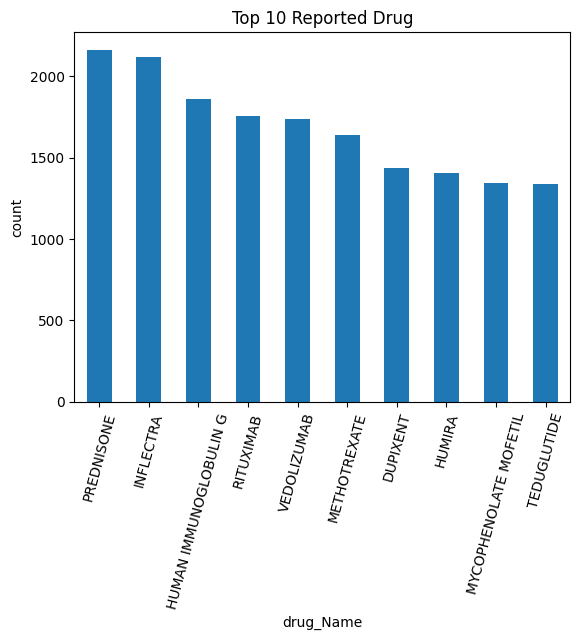

In [12]:
import matplotlib.pyplot as plt
top_drug = df['DRUGNAME_NORM'].value_counts().head(10)
top_drug.plot(kind='bar')
plt.title('Top 10 Reported Drug')
plt.xlabel('drug_Name')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

In [13]:
df[(df['PRR'] > 2) & (df['ROR'] > 2)].head (20)

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
0,10 HYDROXYCAMPTOTHECIN,2024Q4,DEVICE USE ISSUE,3.5,12.5,1089.5,21227563.5,4262.292651,5455.454594
1,10 HYDROXYCAMPTOTHECIN,2024Q4,HEPATIC FAILURE,3.5,12.5,2085.5,21226567.5,2226.692804,2849.886790
2,10 HYDROXYCAMPTOTHECIN,2024Q4,OFF LABEL USE,3.5,12.5,376951.5,20851701.5,12.319271,15.488667
3,10 HYDROXYCAMPTOTHECIN,2024Q4,POST EMBOLISATION SYNDROME,3.5,12.5,17.5,21228635.5,265358.162500,339658.168000
4,10 HYDROXYCAMPTOTHECIN,2024Q4,THERAPEUTIC PRODUCT INEFFECTIVE FOR UNAPPROVED...,3.5,12.5,23.5,21228629.5,197607.142287,252936.862128
5,2 3 DIMERCAPTOSUCCINIC ACID,2024Q4,FEEDING DISORDER,3.5,11.5,2812.5,21225841.5,1761.192036,2296.902655
6,2 3 DIMERCAPTOSUCCINIC ACID,2024Q4,NAUSEA,3.5,11.5,181293.5,21047360.5,27.322285,35.333415
7,2 3 DIMERCAPTOSUCCINIC ACID,2024Q4,SELECTIVE EATING DISORDER,3.5,11.5,56.5,21228597.5,87669.957522,114351.814159
8,2 3 DIMERCAPTOSUCCINIC ACID,2024Q4,VOMITING,3.5,11.5,150826.5,21077827.5,32.841395,42.532254
9,3 HYDROXYBUTYRIC ACID,2024Q4,OVERDOSE,5.5,11.5,40595.5,21188056.5,169.183611,249.619252


In [14]:
df[(df ['PRR'] > 5 ) & (df['ROR'] > 5)].sort_values(by='PRR', ascending=False).head(20)

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
36723,AUVI Q,2024Q4,NO DEVICE MALFUNCTION,16.5,28.5,0.5,21228623.5,1.556766e+07,2.458051e+07
98427,CYSTEAMINE,2024Q4,CERULOPLASMIN DECREASED,3.5,32.5,0.5,21228632.5,4.127790e+06,4.572321e+06
120909,EDEX,2024Q4,FAILED IN VITRO FERTILISATION,10.5,30.5,1.5,21228626.5,3.624400e+06,4.872144e+06
123649,ELMIRON,2024Q4,PIGMENTARY MACULOPATHY,29.5,392.5,0.5,21228246.5,2.967930e+06,3.190998e+06
332145,SUSVIMO,2024Q4,CONJUNCTIVAL EROSION,6.5,96.5,0.5,21228565.5,2.679334e+06,2.859807e+06
294120,QUTENZA,2024Q4,APPLICATION SITE PLAQUE,8.5,138.5,0.5,21228521.5,2.454999e+06,2.605667e+06
249117,NP THYROID,2024Q4,TRI-IODOTHYRONINE UPTAKE ABNORMAL,7.5,122.5,0.5,21228538.5,2.449447e+06,2.599413e+06
300872,RHOPHYLAC,2024Q4,RHESUS ANTIBODIES POSITIVE,4.5,76.5,0.5,21228587.5,2.358732e+06,2.497481e+06
134113,ESPEROCT,2024Q4,ANTI-POLYETHYLENE GLYCOL ANTIBODY PRESENT,5.5,93.5,0.5,21228569.5,2.358730e+06,2.497479e+06
384074,XROMI,2024Q4,RADIATION INTERACTION,4.5,23.5,1.5,21228639.5,2.274497e+06,2.710039e+06


In [15]:
strong_signals = df[(df ['PRR'] > 5 ) & (df['ROR'] > 5)]
strong_signals.sort_values(by='PRR', ascending=False).head(20)

,DRUGNAME_NORM,QTR,PT_NORM,A,B,C,D,PRR,ROR
36723,AUVI Q,2024Q4,NO DEVICE MALFUNCTION,16.5,28.5,0.5,21228623.5,1.556766e+07,2.458051e+07
98427,CYSTEAMINE,2024Q4,CERULOPLASMIN DECREASED,3.5,32.5,0.5,21228632.5,4.127790e+06,4.572321e+06
120909,EDEX,2024Q4,FAILED IN VITRO FERTILISATION,10.5,30.5,1.5,21228626.5,3.624400e+06,4.872144e+06
123649,ELMIRON,2024Q4,PIGMENTARY MACULOPATHY,29.5,392.5,0.5,21228246.5,2.967930e+06,3.190998e+06
332145,SUSVIMO,2024Q4,CONJUNCTIVAL EROSION,6.5,96.5,0.5,21228565.5,2.679334e+06,2.859807e+06
294120,QUTENZA,2024Q4,APPLICATION SITE PLAQUE,8.5,138.5,0.5,21228521.5,2.454999e+06,2.605667e+06
249117,NP THYROID,2024Q4,TRI-IODOTHYRONINE UPTAKE ABNORMAL,7.5,122.5,0.5,21228538.5,2.449447e+06,2.599413e+06
300872,RHOPHYLAC,2024Q4,RHESUS ANTIBODIES POSITIVE,4.5,76.5,0.5,21228587.5,2.358732e+06,2.497481e+06
134113,ESPEROCT,2024Q4,ANTI-POLYETHYLENE GLYCOL ANTIBODY PRESENT,5.5,93.5,0.5,21228569.5,2.358730e+06,2.497479e+06
384074,XROMI,2024Q4,RADIATION INTERACTION,4.5,23.5,1.5,21228639.5,2.274497e+06,2.710039e+06


These adverse events are reported disproportionely high
Possible signal candidates
May require clinical review

In [16]:
top_signals = strong_signals[['DRUGNAME_NORM', 'PT_NORM' , 'PRR', 'ROR']]
top_signals.head(20)

,DRUGNAME_NORM,PT_NORM,PRR,ROR
0,10 HYDROXYCAMPTOTHECIN,DEVICE USE ISSUE,4262.292651,5455.454594
1,10 HYDROXYCAMPTOTHECIN,HEPATIC FAILURE,2226.692804,2849.886790
2,10 HYDROXYCAMPTOTHECIN,OFF LABEL USE,12.319271,15.488667
3,10 HYDROXYCAMPTOTHECIN,POST EMBOLISATION SYNDROME,265358.162500,339658.168000
4,10 HYDROXYCAMPTOTHECIN,THERAPEUTIC PRODUCT INEFFECTIVE FOR UNAPPROVED...,197607.142287,252936.862128
5,2 3 DIMERCAPTOSUCCINIC ACID,FEEDING DISORDER,1761.192036,2296.902655
6,2 3 DIMERCAPTOSUCCINIC ACID,NAUSEA,27.322285,35.333415
7,2 3 DIMERCAPTOSUCCINIC ACID,SELECTIVE EATING DISORDER,87669.957522,114351.814159
8,2 3 DIMERCAPTOSUCCINIC ACID,VOMITING,32.841395,42.532254
9,3 HYDROXYBUTYRIC ACID,OVERDOSE,169.183611,249.619252


In [17]:
top_signals.to_csv('top_safety_signals.csv', index=False)

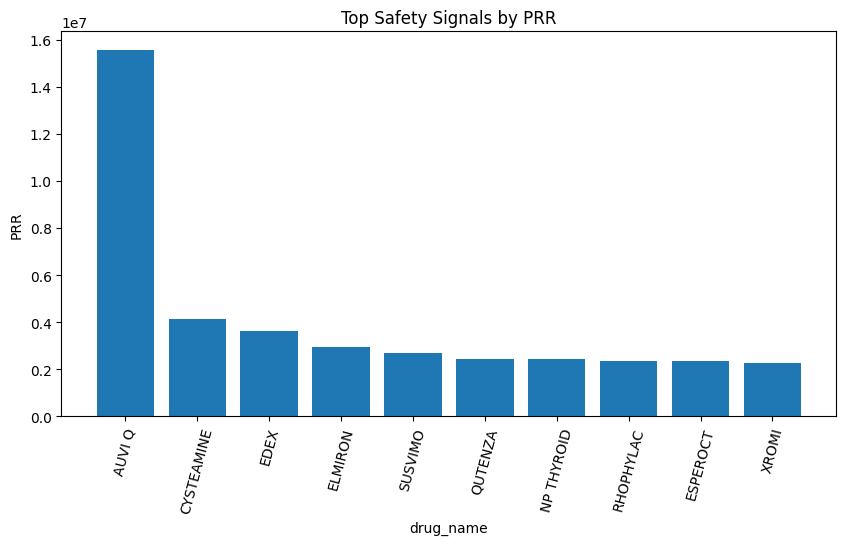

In [18]:
top_10 = top_signals.sort_values(by='PRR', ascending=False).head(10)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(top_10['DRUGNAME_NORM'],top_10['PRR'])
plt.xticks(rotation=75)
plt.title('Top Safety Signals by PRR')
plt.xlabel('drug_name')
plt.ylabel('PRR')
plt.show()